Step-1) Data Cleaning

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [71]:
!python --version


Python 3.12.10


Loading Dataset and combine them

In [72]:
train = pd.read_csv('datasets/customer_churn_dataset-training-master.csv')
test = pd.read_csv('datasets/customer_churn_dataset-testing-master.csv')
df = pd.concat([train, test], ignore_index=True)

In [73]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Removing missing values(if any) and unnecessary columns

In [74]:
df.drop(columns=['CustomerID'], inplace=True)
df.dropna(inplace=True)
print(df.shape)


(505206, 11)


Encoding the columns

In [75]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Verify whether data is cleaned or not

In [76]:
print(df.dtypes)
print(df.isnull().sum().sum())   # should be 0
print(df.head(3))

Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type      int64
Contract Length        int64
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object
0
    Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0  30.0       0    39.0             14.0            5.0           18.0   
1  65.0       0    49.0              1.0           10.0            8.0   
2  55.0       0    14.0              4.0            6.0           18.0   

   Subscription Type  Contract Length  Total Spend  Last Interaction  Churn  
0                  2                0        932.0              17.0    1.0  
1                  0                1        557.0               6.0    1.0  
2                  0                2        185.0               3.0    1.0  


Step 2)Exploratory Data Analysis

i)Churn Distribution

Churn Counts:
 Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

Churn %:
 Churn
1.0    55.52
0.0    44.48
Name: proportion, dtype: float64


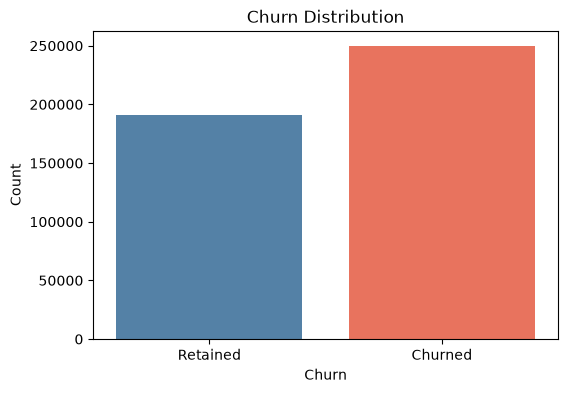

In [77]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
print("Churn Counts:\n", churn_counts)
print("\nChurn %:\n", churn_pct.round(2))
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=train, hue='Churn',
              palette={0: 'steelblue', 1: 'tomato'}, legend=False)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.ylabel('Count')
plt.show()

ii)Churn based on Categories

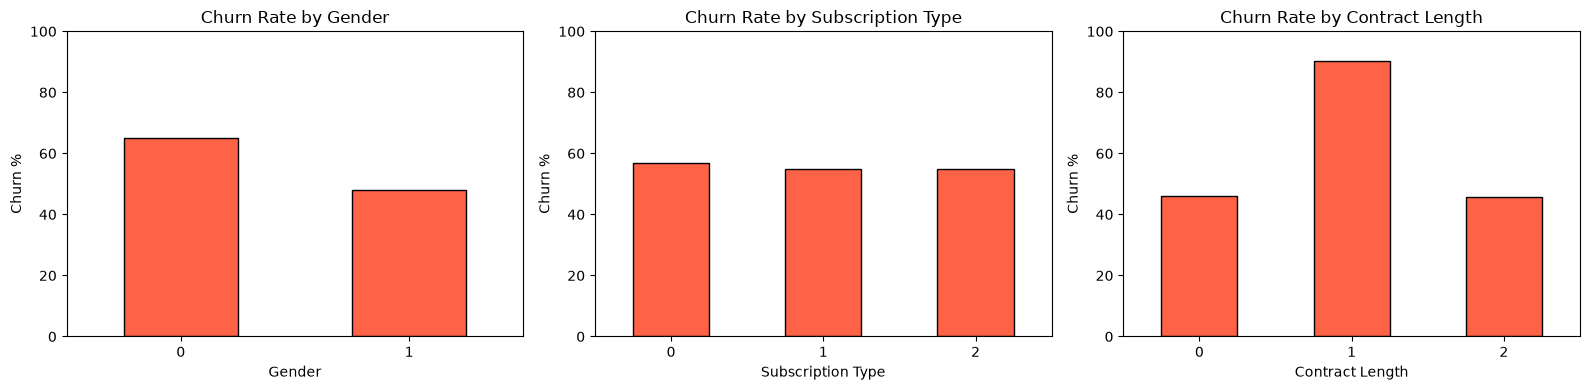

In [78]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='tomato', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

iii)Numerical Feautures vs Churn

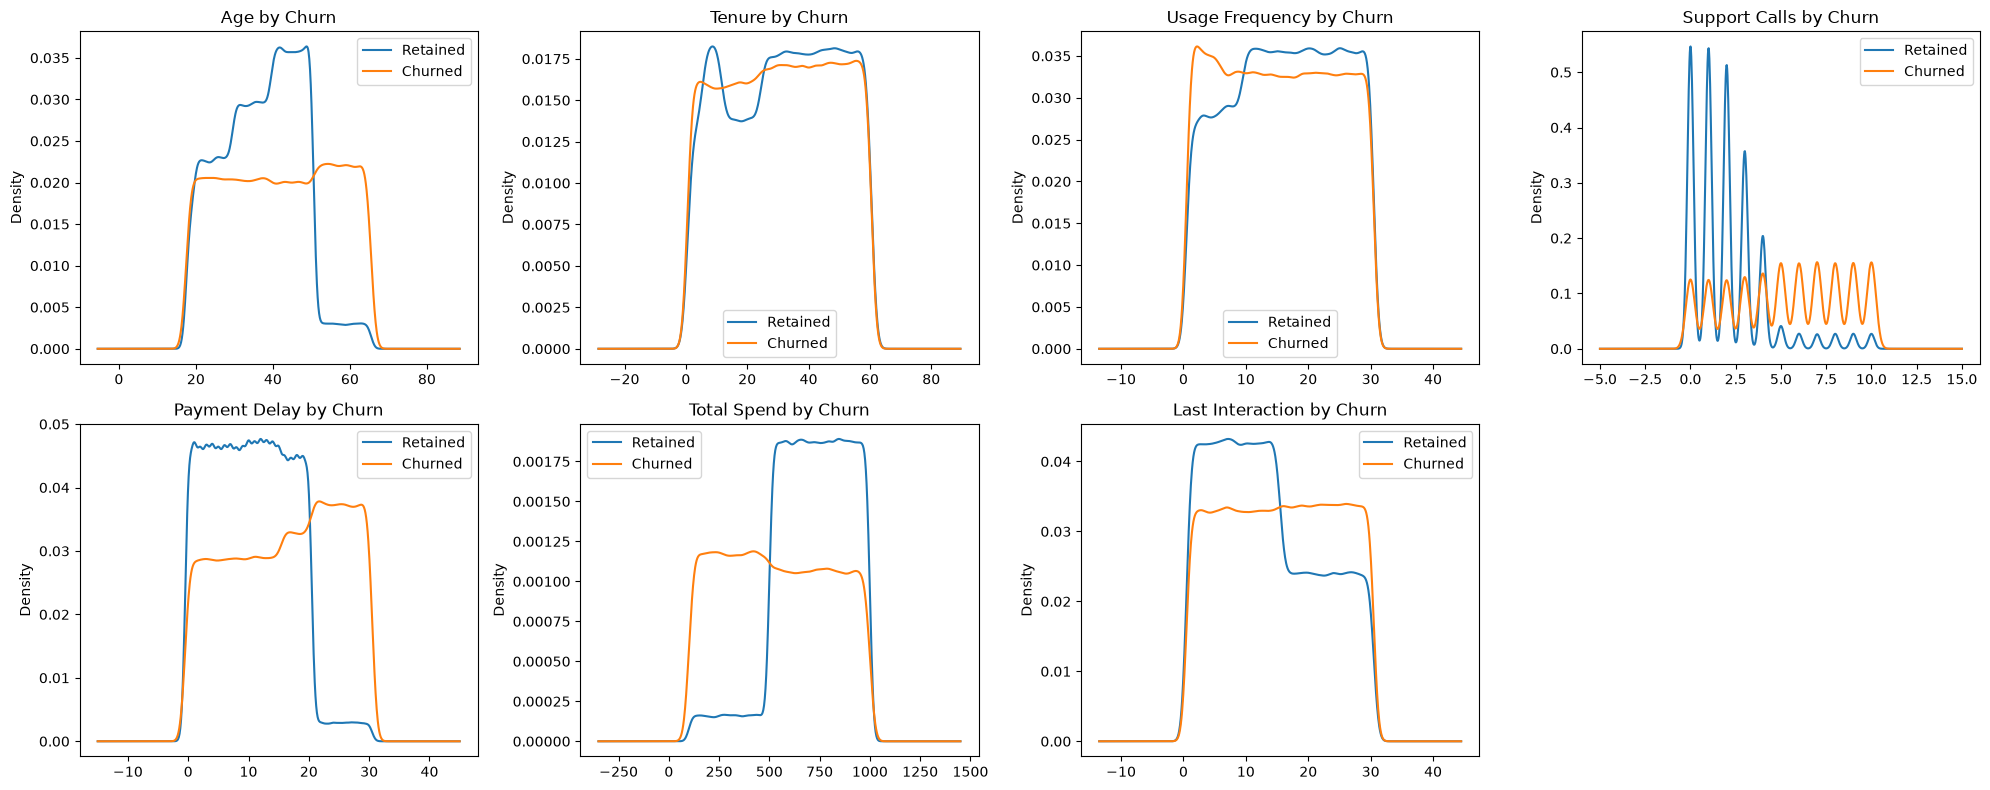

In [79]:
num_cols = ['Age', 'Tenure', 'Usage Frequency',
            'Support Calls', 'Payment Delay',
            'Total Spend', 'Last Interaction']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.groupby('Churn')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} by Churn')
    axes[i].legend(['Retained', 'Churned'])
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

iv) Correlation Heatmap

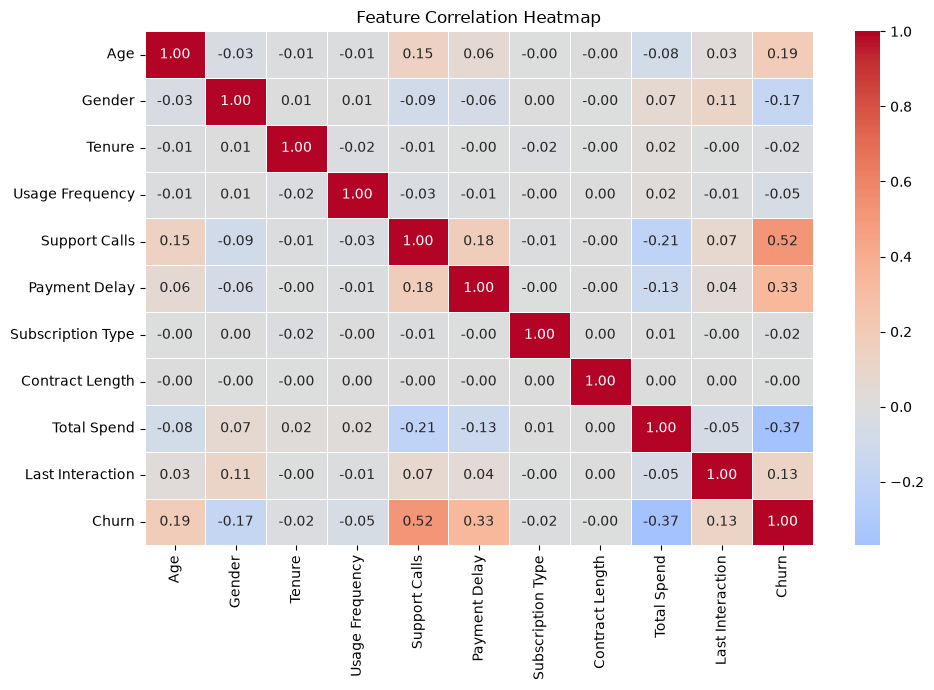


Top correlations with Churn:
Support Calls        0.516283
Payment Delay        0.329785
Age                  0.191224
Last Interaction     0.127150
Contract Length     -0.001909
Subscription Type   -0.015599
Tenure              -0.021308
Usage Frequency     -0.053263
Gender              -0.168989
Total Spend         -0.369682
Name: Churn, dtype: float64


In [80]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr,annot=True, fmt='.2f',cmap='coolwarm',center=0,linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nTop correlations with Churn:")
print(corr['Churn'].drop('Churn').sort_values(ascending=False))

Step 3-Feature Engineering

i)High Support Flag: Customers with many support calls are
high risk

In [81]:
df['High Support'] = (df['Support Calls'] >= 5).astype(int)

ii)Payment Risk Flag:Customers with high payment delay are high risk

In [82]:
df['Payment Risk'] = (df['Payment Delay'] >= 20).astype(int)

iii)Engagement Score

In [83]:
df['Engagement Score'] = df['Usage Frequency'] / (df['Last Interaction'] + 1)


iv)Spend per Tenure

In [84]:
df['Spend per Tenure'] = df['Total Spend'] / (df['Tenure'] + 1)


v)New Customer:New customers(low tenure) tend to churn more

In [85]:
df['Is New Customer'] = (df['Tenure'] <= 6).astype(int)

Displaying New Features

In [86]:
print(df[['High Support', 'Payment Risk', 'Engagement Score','Spend per Tenure', 'Is New Customer']].head())

   High Support  Payment Risk  Engagement Score  Spend per Tenure  \
0             1             0          0.777778         23.300000   
1             1             0          0.142857         11.140000   
2             1             0          1.000000         12.333333   
3             1             0          0.700000         10.153846   
4             1             0          0.952381         18.696970   

   Is New Customer  
0                0  
1                0  
2                0  
3                0  
4                0  


Churn Rates of new **Features**

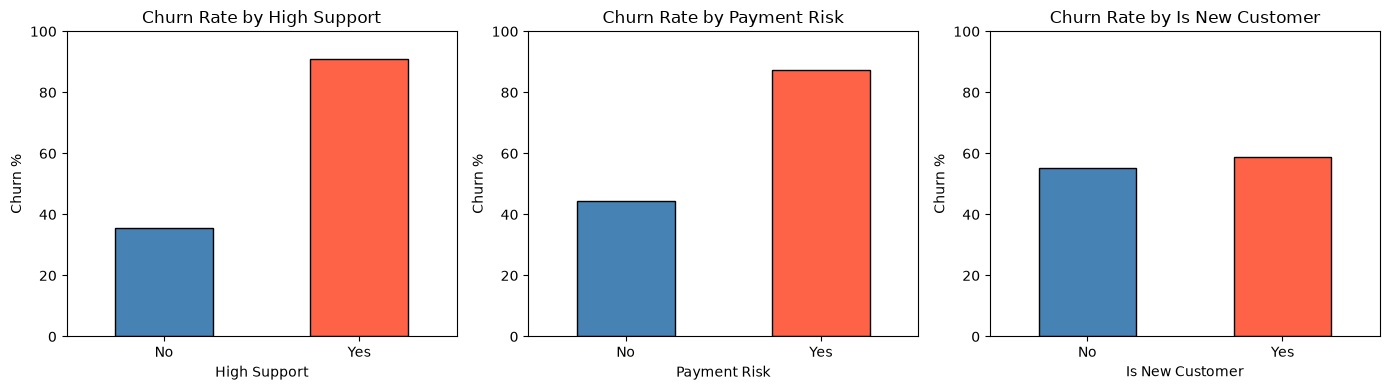

In [87]:
new_features= ['High Support', 'Payment Risk', 'Is New Customer']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(new_features):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].set_ylim(0, 100)
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

**Step 4)Modeling**

i)Train/Test split & Scaling

In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("X_train_scaled shape:", X_train_scaled.shape)

X_train_scaled shape: (404164, 15)


**Logistic Regression**

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

C:\MyProjects\churnapp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Accuracy: 0.8442
              precision    recall  f1-score   support

    Retained       0.81      0.85      0.83     44943
     Churned       0.88      0.84      0.86     56099

    accuracy                           0.84    101042
   macro avg       0.84      0.85      0.84    101042
weighted avg       0.85      0.84      0.84    101042



**Random Forest**


In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=['Retained', 'Churned']
    )
)

Accuracy: 0.9359
              precision    recall  f1-score   support

    Retained       1.00      0.86      0.92     44943
     Churned       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042



**XGBoost**

In [91]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42,eval_metric='logloss',n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))

Accuracy: 0.9336
              precision    recall  f1-score   support

    Retained       0.99      0.86      0.92     44943
     Churned       0.90      0.99      0.94     56099

    accuracy                           0.93    101042
   macro avg       0.94      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



**Comparision of the models**

Logistic Regression       → Accuracy: 0.8442
Random Forest             → Accuracy: 0.9359
XGBoost                   → Accuracy: 0.9336


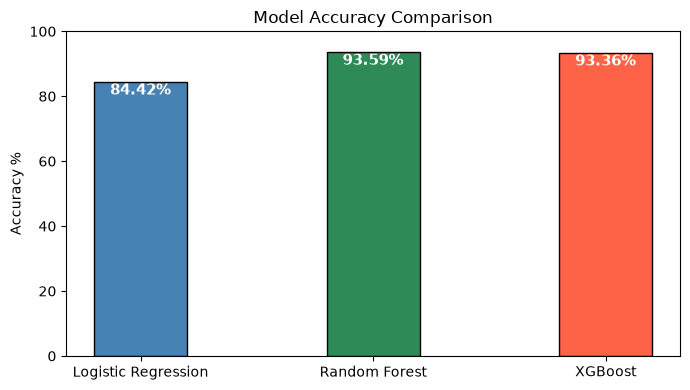

In [92]:
results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Random Forest'      : accuracy_score(y_test, rf_pred),
    'XGBoost'            : accuracy_score(y_test, xgb_pred)
}
for model, acc in results.items():
    print(f"{model:25s} → Accuracy: {acc:.4f}")
plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=['steelblue', 'seagreen', 'tomato'],
               edgecolor='black', width=0.4)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 5,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='white'
    )

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Step 5) Evaluation and Feature importance

Classification Report

In [93]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

best_pred = rf.predict(X_test_scaled)
best_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(
    y_test,
    best_pred,
    target_names=['Retained', 'Churned']
))

              precision    recall  f1-score   support

    Retained       1.00      0.86      0.92     44943
     Churned       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042



Confusion matrix

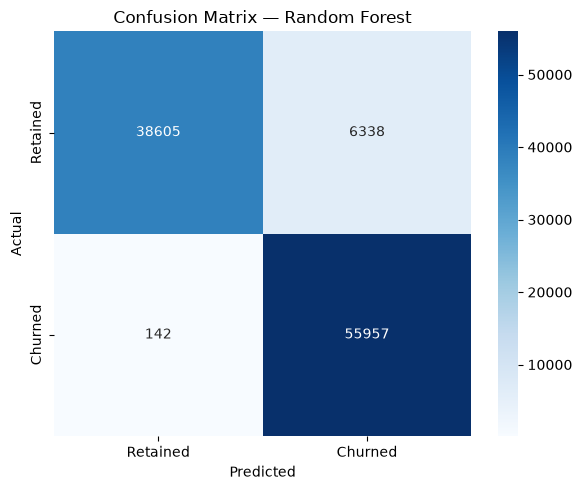


True Negatives  (Correctly predicted Retained): 38605
False Positives (Predicted Churn, Actually Retained): 6338
False Negatives (Predicted Retained, Actually Churned): 142
True Positives  (Correctly predicted Churned): 55957


In [94]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly predicted Retained): {tn}")
print(f"False Positives (Predicted Churn, Actually Retained): {fp}")
print(f"False Negatives (Predicted Retained, Actually Churned): {fn}")
print(f"True Positives  (Correctly predicted Churned): {tp}")

ROC AUC curve

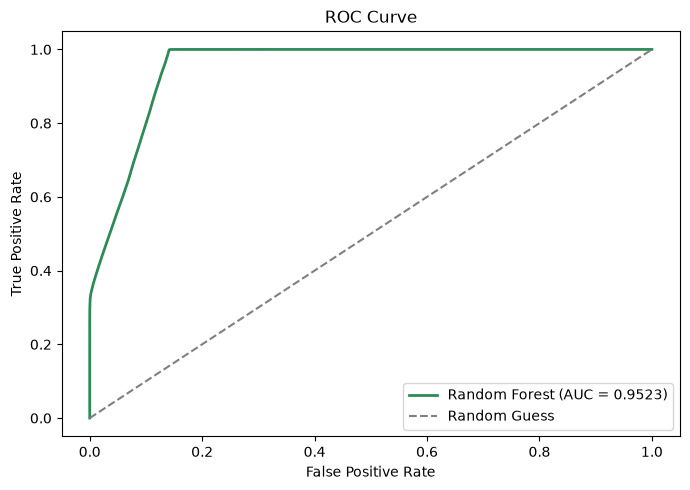

AUC Score: 0.9523


In [95]:
fpr, tpr, _ = roc_curve(y_test, best_prob)
auc_score   = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='seagreen', lw=2, label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

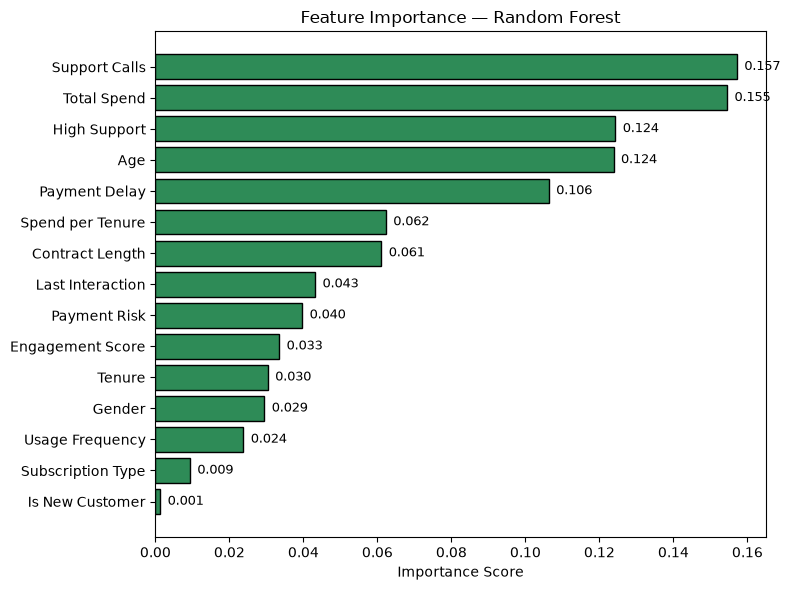


Feature Importance Ranking:
Support Calls        0.1572
Total Spend          0.1545
High Support         0.1243
Age                  0.1238
Payment Delay        0.1063
Spend per Tenure     0.0623
Contract Length      0.0611
Last Interaction     0.0432
Payment Risk         0.0397
Engagement Score     0.0335
Tenure               0.0304
Gender               0.0294
Usage Frequency      0.0238
Subscription Type    0.0093
Is New Customer      0.0013
dtype: float64


In [96]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)
plt.figure(figsize=(8, 6))
bars = plt.barh(importances.index, importances.values,
                color='seagreen', edgecolor='black')
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.3f}',
        va='center', fontsize=9
    )
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print("\nFeature Importance Ranking:")
print(importances.sort_values(ascending=False).round(4))

In [97]:
def predict_churn(customer_data):
    input_df = pd.DataFrame([{
        'Age':               customer_data['Age'],
        'Gender':            customer_data['Gender'],
        'Tenure':            customer_data['Tenure'],
        'Usage Frequency':   customer_data['Usage Frequency'],
        'Support Calls':     customer_data['Support Calls'],
        'Payment Delay':     customer_data['Payment Delay'],
        'Subscription Type': customer_data['Subscription Type'],
        'Contract Length':   customer_data['Contract Length'],
        'Total Spend':       customer_data['Total Spend'],
        'Last Interaction':  customer_data['Last Interaction']
    }])


    input_df['High Support']     = (input_df['Support Calls'] >= 5).astype(int)
    input_df['Payment Risk']     = (input_df['Payment Delay'] >= 20).astype(int)
    input_df['Engagement Score'] = input_df['Usage Frequency'] / (input_df['Last Interaction'] + 1)
    input_df['Spend per Tenure'] = input_df['Total Spend'] / (input_df['Tenure'] + 1)
    input_df['Is New Customer']  = (input_df['Tenure'] <= 6).astype(int)


    input_df = input_df[X_train.columns]


    prediction  = rf.predict(input_df)[0]
    probability = rf.predict_proba(input_df)[0][1] * 100


    if probability >= 70:
        risk = "High Risk"
    elif probability >= 40:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"



    print("CHURN PREDICTION RESULT")

    print(f"  Prediction  : {'CHURNED ' if prediction == 1 else 'RETAINED '}")
    print(f"  Probability : {probability:.2f}%")
    print(f"  Risk Level  : {risk}")


    return prediction, probability, risk

In [98]:
high_risk_customer = {
    'Age':               42,
    'Gender':            1,
    'Tenure':            5,
    'Usage Frequency':   4,
    'Support Calls':     8,
    'Payment Delay':     25,
    'Subscription Type': 0,
    'Contract Length':   1,
    'Total Spend':       280,
    'Last Interaction':  28
}

predict_churn(high_risk_customer)

CHURN PREDICTION RESULT
  Prediction  : CHURNED 
  Probability : 86.00%
  Risk Level  : High Risk


C:\MyProjects\churnapp\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\MyProjects\churnapp\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


(np.int64(1), np.float64(86.0), 'High Risk')

In [99]:
low_risk_customer = {
    'Age':               35,
    'Gender':            0,
    'Tenure':            48,
    'Usage Frequency':   25,
    'Support Calls':     1,
    'Payment Delay':     2,
    'Subscription Type': 1,
    'Contract Length':   0,
    'Total Spend':       890,
    'Last Interaction':  3
}

predict_churn(low_risk_customer)

CHURN PREDICTION RESULT
  Prediction  : CHURNED 
  Probability : 74.00%
  Risk Level  : High Risk


C:\MyProjects\churnapp\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\MyProjects\churnapp\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


(np.int64(1), np.float64(74.0), 'High Risk')